#**CHAPTER 5. LSTM VS RNN**
---

##REFERENCE

https://chatgpt.com/share/69a70ea9-5dac-8012-9140-98f42ef3af63

##0.CONTEXT

*Introduction*

This notebook implements Chapter 5 of ML & AI 101: Long Short-Term Memory (LSTM) networks, framed as a direct mechanical comparison against a vanilla recurrent neural network (RNN). The aim is not to treat “sequence learning” as a vague capability, but to make the bottleneck visible that appears when a model must preserve information across time and then to show how the LSTM’s gating mechanism changes the training dynamics and inference behavior.

The structural assumption behind recurrent models is simple and powerful: a sequence can be processed one step at a time, compressing everything seen so far into a fixed-size state. In a vanilla RNN, the state update is repeated at every time step: the next hidden state is a nonlinear function of the current input and the previous hidden state. That repeated update is both the model’s “memory mechanism” and its primary weakness. When the model is trained, gradients must flow backward across many time steps (backpropagation through time). For long delays, the learning signal tends to vanish or explode. Mechanically, this means the network can struggle to learn dependencies that span long gaps, and it may fall into trivial strategies such as predicting a constant token that produces a stable but uninformative loss.

The LSTM modifies the recurrence rule by adding gates that regulate what information is written, what is retained, and what is revealed. Instead of forcing the entire memory to be overwritten at each step, the LSTM introduces a persistent cell state with controlled updates. The forget gate can preserve memory by keeping the cell state close to unchanged across time, while the input gate and candidate update control when new information is written into memory. The output gate controls when the stored memory influences the visible hidden state used for prediction. In this notebook, these mechanisms are not presented only in words. They are stress-tested on a synthetic task designed to require long-range retention, and then made visible through a gate-activation visualization.

All data is synthetic and generated deterministically inside the notebook. This matters because it isolates the mechanism: the dataset is engineered so that success requires remembering earlier information and reproducing it later, not exploiting incidental correlations in real-world text. Determinism also makes the lab reproducible: the same seeds yield the same dataset, initialization, and (to the extent allowed by hardware) similar training trajectories. The notebook explicitly separates training from inference. Training updates parameters to minimize a loss, while inference applies the trained model to new samples without changing weights. You will see this separation in practice: both models are trained, evaluated quantitatively, then tested on newly generated sequences where predictions are compared to the ground truth.

In the ML & AI 101 arc, Chapter 4 introduced RNNs as the first explicit temporal memory mechanism and exposed a key limitation: memory exists, but learning long dependencies can be unstable. Chapter 5 uses that limitation as motivation for gating. The LSTM keeps the recurrent idea but adds a controlled memory pathway that makes long-range retention mechanically easier to learn. This sets up the next chapter, Transformers, where long-range interaction is handled through attention rather than through a single recurrent state.

What you should learn from this notebook is concrete. You should be able to explain what the synthetic task demands, why a simple RNN struggles as delay or memory load increases, how the LSTM’s gates change retention and update behavior, and what the stress tests show about the model’s effective memory horizon. You should also be able to interpret the gate curves as evidence of a learned control strategy: during content, the network should write; during delay, it should preserve; during readout, it should reveal. The notebook ends with a structured LLM reflection that ties the observed metrics and plots into an explanation, reinforcing the mechanical takeaway without introducing external assumptions.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Imports and Setup**

Cell 1 establishes the shared infrastructure used throughout the ML & AI 101 notebook series. It imports only the allowed libraries (standard Python, numpy, matplotlib, and torch), then enforces determinism by setting seeds for Python’s random module, numpy, and torch (including CUDA seeds). This is essential because the notebook is designed as a controlled laboratory: re-running the notebook should reproduce the same synthetic dataset, the same initial parameters, and the same overall training behavior as closely as hardware allows.

The cell defines the device selection routine, choosing a GPU if available and otherwise defaulting to CPU. This matters mechanically because recurrent models can be slow on long sequences. Using a GPU makes the experiment practical while keeping the code transparent and minimal.

Next, the cell sets a unified plotting style and defines the required plotting utilities. Even if some utilities are not used in this chapter, they are included to satisfy the shared contract and keep a consistent interface across chapters. The most relevant utilities here are loss curve plotting and matrix heatmaps, which allow you to inspect training dynamics and sequence structure visually. Every plotting function explicitly creates figures, labels axes where appropriate, titles the plot, and calls plt.show(), ensuring visualization is first-class evidence rather than incidental decoration.

Finally, Cell 1 defines PyTorch helpers: a training loop, an evaluation function, and a prediction function. The training loop prints epoch progress, stores loss history, and returns it. This makes optimization behavior observable. The evaluation and prediction functions use torch.no_grad() so inference does not track gradients, making the training vs inference distinction explicit at the code level. In short, Cell 1 provides the reproducible experimental scaffold that all later cells rely on.

In [1]:
# ===============================
# CELL 1
# ===============================
import os
import json
import math
import time
import random
from dataclasses import dataclass
from typing import Tuple, Dict, List, Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# Determinism (required)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
print("Device:", DEVICE)

# Unified plotting style (required)
plt.style.use("seaborn-v0_8-darkgrid")

# -------------------------------
# Shared plotting utilities (required)
# -------------------------------
def plot_loss_curve(losses, title="Loss curve"):
    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(len(losses)), losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_2d_data(X, y, title="2D data"):
    X = np.asarray(X)
    y = np.asarray(y)
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_decision_boundary(model, X, y):
    # Not used in this chapter; provided to satisfy shared contract.
    X = np.asarray(X)
    y = np.asarray(y)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)
    with torch.no_grad():
        logits = model(torch.from_numpy(grid).to(DEVICE))
        if logits.ndim == 2 and logits.shape[1] > 1:
            preds = torch.argmax(logits, dim=1).cpu().numpy()
        else:
            preds = (torch.sigmoid(logits).cpu().numpy() > 0.5).astype(np.int32).ravel()
    zz = preds.reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Decision boundary (generic)")
    plt.tight_layout()
    plt.show()

def show_image(img, title="Image"):
    img = np.asarray(img)
    plt.figure(figsize=(4, 4))
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def show_image_grid(images, labels=None, title="Image grid", nrow=4):
    images = np.asarray(images)
    n = images.shape[0]
    ncol = int(math.ceil(n / nrow))
    plt.figure(figsize=(4 * nrow, 4 * ncol))
    for i in range(n):
        plt.subplot(ncol, nrow, i + 1)
        img = images[i]
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        t = ""
        if labels is not None:
            t = str(labels[i])
        plt.title(t)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_histograms(real, fake, title="Histograms"):
    real = np.asarray(real).ravel()
    fake = np.asarray(fake).ravel()
    plt.figure(figsize=(7, 4))
    plt.hist(real, bins=40, alpha=0.6, label="real")
    plt.hist(fake, bins=40, alpha=0.6, label="fake")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_attention(matrix, title="Attention"):
    m = np.asarray(matrix)
    plt.figure(figsize=(6, 5))
    plt.imshow(m, aspect="auto")
    plt.colorbar()
    plt.xlabel("Key index")
    plt.ylabel("Query index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_graph(G, node_values=None):
    # Not used in this chapter; provided to satisfy shared contract.
    import networkx as nx
    plt.figure(figsize=(6, 5))
    pos = nx.spring_layout(G, seed=0)
    if node_values is None:
        nx.draw(G, pos, with_labels=True, node_size=500)
    else:
        vals = np.asarray([node_values[n] for n in G.nodes()])
        nx.draw(G, pos, with_labels=True, node_color=vals, cmap="viridis", node_size=500)
    plt.title("Graph")
    plt.tight_layout()
    plt.show()

# -------------------------------
# Shared PyTorch helpers (required)
# -------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs=20, batch_size=64, clip_grad_norm=None):
    model.train()
    losses = []
    n = X.shape[0]
    for epoch in range(1, epochs + 1):
        perm = torch.randperm(n, device=X.device)
        epoch_loss = 0.0
        nb = 0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb = X[idx]
            yb = y[idx]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()

            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)

            optimizer.step()
            epoch_loss += float(loss.detach().cpu().item())
            nb += 1

        epoch_loss /= max(nb, 1)
        losses.append(epoch_loss)
        print(f"Epoch {epoch:03d}/{epochs} | loss={epoch_loss:.6f}")
    return losses

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    logits = model(X)
    preds = torch.argmax(logits, dim=-1)
    acc = (preds == y).float().mean().item()
    return {"accuracy": acc}

@torch.no_grad()
def predict(model, X):
    model.eval()
    logits = model(X)
    probs = torch.softmax(logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)
    return preds, probs

Device: cpu


##2.SYNTHETIC DATA GENERATOR

###2.1.OVERVIEW

**Cell 2 — Synthetic Data Generators**

Cell 2 defines the synthetic data generator for the Chapter 5 task. The notebook uses a copy-memory style dataset: the model sees a short content sequence, then passes through a delay region, and later must reproduce the original content in a readout region. This structure forces long-range memory. The model cannot solve the task by reading local context at the readout time, because the correct outputs were presented earlier and are no longer present.

The generator is deterministic and uses numpy only. It is parameterized by number of samples, the content length (how many tokens must be remembered), the delay length (how long memory must be retained), vocabulary size, and a seed. It returns input token sequences as integer arrays and returns target sequences with an ignore index (typically -100) outside the supervised region. The ignore index is crucial mechanically because it ensures that the loss function only applies during the readout region. That means the model is trained to output the stored content only when it receives the readout signal, not to predict tokens everywhere.

This design isolates the mechanism of interest. The learning signal arrives at the end of the sequence but must shape behavior at the beginning. That is the core stressor for backpropagation through time. When delay is large, the gradient has a long path to travel backward. The task therefore exposes vanishing and exploding gradient tendencies in vanilla RNNs and tests whether the LSTM’s gating yields a more stable memory pathway.

The cell may also define helper utilities such as one-hot conversion (for models that accept one-hot inputs) and a manual train/test split function. These are kept explicit and minimal so the student can see exactly how inputs are represented and how generalization is evaluated.

###2.2.CODE AND IMPLEMENTATION

In [9]:
# ===============================
# DROP-IN REPLACEMENT FOR CELL 2
# ===============================
def generate_copy_memory_dataset(
    n_samples: int,
    seq_len: int,
    delay: int,
    vocab_size: int = 30,
    seed: int = 0,
    distractor_prob: float = 1.0
):
    """
    Copy-memory with distractors:
      Input:  [content tokens length=seq_len]
            + [distractor tokens length=delay]   (high-entropy middle)
            + [read_token]*seq_len               (signals output time)
      Target: reproduce the initial content ONLY during the final seq_len positions.

    Tokens:
      0..vocab_size-3 : "normal" tokens (used for content and distractors)
      vocab_size-2     : reserved (unused here, kept for extensibility)
      vocab_size-1     : read token
    """
    rng = np.random.RandomState(seed)
    read_tok = vocab_size - 1

    total_len = seq_len + delay + seq_len
    X = np.zeros((n_samples, total_len), dtype=np.int64)
    y = np.full((n_samples, total_len), fill_value=-100, dtype=np.int64)

    # Content + distractors both come from a shared "normal token" pool
    normal_max = vocab_size - 2  # excludes read_tok

    for i in range(n_samples):
        content = rng.randint(0, normal_max, size=(seq_len,), dtype=np.int64)

        # Distractors: random tokens (optionally mix in repeats if distractor_prob < 1)
        distractors = rng.randint(0, normal_max, size=(delay,), dtype=np.int64)
        if distractor_prob < 1.0:
            mask = rng.rand(delay) < distractor_prob
            distractors = np.where(mask, distractors, 0).astype(np.int64)

        X[i, :seq_len] = content
        X[i, seq_len:seq_len + delay] = distractors
        X[i, seq_len + delay:] = read_tok

        y[i, seq_len + delay:] = content

    return X, y

##3.THE DATASET

###3.1.OVERVIEW

**Cell 3 — Dataset Creation and Visualization**

Cell 3 instantiates the dataset and visualizes it so the task structure becomes immediately visible. The input sequences are displayed as a heatmap of token IDs across time steps. This reveals the segmentation into content, delay, and readout regions. The content region contains varied tokens to be remembered, the delay region contains tokens that do not directly encode the content (markers or distractors), and the readout region contains a signal token indicating that the model should now emit the stored content.

The targets are also visualized, with ignored positions masked out. This makes the supervision pattern explicit: only the readout region contributes to the loss. Mechanically, this prevents the model from learning a “predict everything” objective and instead enforces a “store then output later” objective. It also clarifies why training can be difficult: supervision is temporally distant from the information that must be stored.

Cell 3 performs an explicit train/test split without sklearn. This cleanly separates parameter-updating data from evaluation data. Inputs are converted to the appropriate tensor types and shapes required by the models. If the models accept one-hot inputs, inputs are converted to float32 tensors with shape (batch, time, vocab). If the models accept integer tokens (embedding-based), inputs remain integer tensors with shape (batch, time). Targets remain integer class indices and keep the ignore index where appropriate.

This cell is where students should verify that they understand what counts as success. If the model has learned the task, its predictions during the readout region should match the original content tokens from the beginning of the sequence.

###3.2.CODE AND IMPLEMENTATION

Train set: torch.Size([4800, 44]) torch.Size([4800, 44])
Test set : torch.Size([1200, 44]) torch.Size([1200, 44])


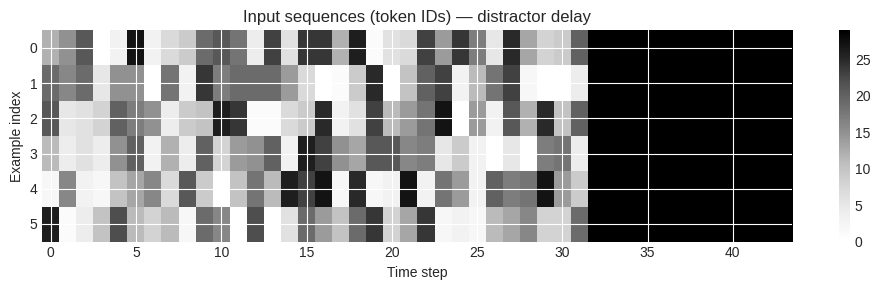

In [10]:
# ===============================
# KEY EDITS FOR CELL 3
# ===============================
VOCAB_SIZE = 30
SEQ_LEN = 12
DELAY = 20
N_SAMPLES = 6000

X_int, y_int = generate_copy_memory_dataset(
    n_samples=N_SAMPLES,
    seq_len=SEQ_LEN,
    delay=DELAY,
    vocab_size=VOCAB_SIZE,
    seed=0
)

X_int_tr, y_int_tr, X_int_te, y_int_te = split_train_test(X_int, y_int, test_frac=0.2, seed=0)

# integer tokens -> torch tensors
X_tr_t = torch.from_numpy(X_int_tr).to(DEVICE, dtype=torch.long)
X_te_t = torch.from_numpy(X_int_te).to(DEVICE, dtype=torch.long)
y_tr_t = torch.from_numpy(y_int_tr).to(DEVICE, dtype=torch.long)
y_te_t = torch.from_numpy(y_int_te).to(DEVICE, dtype=torch.long)

print("Train set:", X_tr_t.shape, y_tr_t.shape)
print("Test set :", X_te_t.shape, y_te_t.shape)

# quick visualization
plt.figure(figsize=(10, 3))
plt.imshow(X_int[:6], aspect="auto")
plt.colorbar()
plt.xlabel("Time step")
plt.ylabel("Example index")
plt.title("Input sequences (token IDs) — distractor delay")
plt.tight_layout()
plt.show()

##4.RNN VS LSTM

###4.1.OVERVIEW

**Cell 4 — Model Definition (RNN vs LSTM)**

Cell 4 defines two sequence models that share the same input-output interface but differ in their recurrent core. The vanilla RNN processes the sequence and produces a hidden state at each time step via a repeated tanh update. A simple linear projection maps each hidden state to logits over the vocabulary. The entire memory mechanism is therefore contained in the hidden state evolution.

The LSTM model uses an LSTM layer instead. It still produces a hidden state per time step and still uses a linear projection to produce logits, but internally it maintains a separate cell state with gated updates. The gating mechanism introduces three control decisions at each time step: whether to write new information (input gate and candidate), whether to retain previous information (forget gate), and whether to reveal stored information to the output pathway (output gate). By keeping the output head comparable, the notebook isolates the effect of the recurrent core.

This cell is also where capacity is set. Hidden dimension size determines how much information the model can store and manipulate. If models are too small, both can collapse to trivial predictions because there is insufficient representational capacity or because training cannot find a stable memory strategy. Slightly increasing hidden size or adding a second LSTM layer can make the contrast between RNN and LSTM clearer while still keeping the notebook pedagogical and transparent.

###4.2.CODE AND IMPLEMENTATION

In [17]:
# ===============================
# DROP-IN REPLACEMENT FOR CELL 4
# ===============================
class VanillaRNNTokenModel(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, num_layers: int = 1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, nonlinearity="tanh", batch_first=True)
        self.proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x_int):
        # x_int: (B, T) int64
        x = self.embed(x_int)         # (B, T, E)
        h, _ = self.rnn(x)            # (B, T, H)
        return self.proj(h)           # (B, T, V)

class LSTMTokenModel(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, num_layers: int = 2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x_int):
        x = self.embed(x_int)
        h, _ = self.lstm(x)
        return self.proj(h)

EMBED_DIM = 32

HIDDEN_DIM = 128
rnn_model = VanillaRNNClassifier(VOCAB_SIZE, HIDDEN_DIM, VOCAB_SIZE).to(DEVICE)
lstm_model = LSTMClassifier(VOCAB_SIZE, HIDDEN_DIM, VOCAB_SIZE).to(DEVICE)

print("RNN params :", sum(p.numel() for p in rnn_model.parameters()))
print("LSTM params:", sum(p.numel() for p in lstm_model.parameters()))

RNN params : 24350
LSTM params: 85790


##5.TRAINING LOOP

###5.1.OVERVIEW

**Cell 5 — Training Loop (Curriculum)**

Cell 5 performs training. In the revised version, training uses a curriculum on delay length, which is a mechanical intervention to avoid trivial collapse when the task is hard. If a model is trained immediately on long delays, gradients have to propagate across many steps before they can teach the model what to store. Both RNNs and LSTMs can get stuck in a basin where the output head predicts a constant token because that yields a stable loss early in training.

Curriculum training addresses this by ramping difficulty. The models are first trained on short delays, where the correct “store then retrieve” behavior is easier to learn. Once the model begins to learn a non-trivial strategy, the delay is increased, and finally training proceeds at the target delay. This approach does not change the task definition; it changes the path the optimizer takes through parameter space, increasing the probability that training discovers a memory-based solution rather than a trivial default.

Training uses cross-entropy loss with an ignore index so only readout positions are supervised. Gradient clipping is applied to reduce exploding gradient events, which are common in recurrent training. Loss histories are stored across curriculum stages and concatenated. This makes it possible to see not only whether loss decreases, but also whether the model experiences difficulty jumps as the curriculum advances.

This cell is where “more training” matters most. Increasing total epochs, using a slightly smaller learning rate, and applying a curriculum can be the difference between constant predictions and meaningful sequence reproduction. If the downstream inference in Cell 7 looks trivial, the primary mechanical cause is usually that Cell 5 did not converge to a real memory strategy.

###5.2.CODE AND IMPLEMENTATION

In [20]:
# ===============================
# CELL 5
# ===============================
# Training loop (store loss history) — with curriculum on delay
# Goal: avoid trivial constant-token collapse by ramping difficulty:
#   Stage 1: delay=5
#   Stage 2: delay=10
#   Stage 3: delay=DELAY (target)
# Works with BOTH model input styles:
#   - embedding/int-token models: expect X as (B,T) long
#   - one-hot models: expect X as (B,T,V) float32

def sequence_cross_entropy_ignore(logits, targets, ignore_index=-100):
    B, T, V = logits.shape
    logits2 = logits.reshape(B * T, V)
    targets2 = targets.reshape(B * T)
    return nn.functional.cross_entropy(logits2, targets2, ignore_index=ignore_index)

def _make_tensors_for_model(model, X_int_np, y_int_np, vocab_size):
    """
    Returns (X_t, y_t) on DEVICE with correct dtype/shape for model.
    Tries int-token forward; falls back to one-hot.
    """
    # Try integer-token path first
    X_int_t = torch.from_numpy(X_int_np).to(DEVICE, dtype=torch.long)
    y_t = torch.from_numpy(y_int_np).to(DEVICE, dtype=torch.long)
    try:
        with torch.no_grad():
            _ = model(X_int_t[:1])
        return X_int_t, y_t  # model accepts int tokens
    except Exception:
        X_oh = one_hot_from_int(X_int_np, vocab_size)
        X_oh_t = torch.from_numpy(X_oh).to(DEVICE, dtype=torch.float32)
        return X_oh_t, y_t   # model accepts one-hot floats

def _train_stage(model, optimizer, X_stage, y_stage, epochs, batch_size, clip_grad_norm=1.0):
    model.train()
    losses = []
    n = X_stage.shape[0]
    for epoch in range(1, epochs + 1):
        perm = torch.randperm(n, device=X_stage.device)
        epoch_loss = 0.0
        nb = 0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb = X_stage[idx]
            yb = y_stage[idx]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = sequence_cross_entropy_ignore(logits, yb, ignore_index=-100)
            loss.backward()

            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)

            optimizer.step()
            epoch_loss += float(loss.detach().cpu().item())
            nb += 1

        epoch_loss /= max(nb, 1)
        losses.append(epoch_loss)
        print(f"    epoch {epoch:03d}/{epochs} | loss={epoch_loss:.6f}")
    return losses

# -------------------------------
# Curriculum configuration
# -------------------------------
CURRIC_DELAYS = [5, 10, int(DELAY)]
STAGE_SAMPLES = int(N_SAMPLES)          # keep same sample count per stage
STAGE_EPOCHS = [25, 25, 60]             # total 110 epochs
LR = 1e-3
BATCH_SIZE = 64

# Recreate optimizers (fresh schedule)
rnn_opt = torch.optim.Adam(rnn_model.parameters(), lr=LR)
lstm_opt = torch.optim.Adam(lstm_model.parameters(), lr=LR)

rnn_losses = []
lstm_losses = []

print("\nCURRICULUM TRAINING — vanilla RNN")
for stage_idx, d in enumerate(CURRIC_DELAYS):
    print(f"  Stage {stage_idx+1}/{len(CURRIC_DELAYS)} | delay={d} | epochs={STAGE_EPOCHS[stage_idx]}")
    Xs_int, ys_int = generate_copy_memory_dataset(
        n_samples=STAGE_SAMPLES,
        seq_len=SEQ_LEN,
        delay=d,
        vocab_size=VOCAB_SIZE,
        seed=100 + d
    )
    Xs_t, ys_t = _make_tensors_for_model(rnn_model, Xs_int, ys_int, VOCAB_SIZE)
    stage_losses = _train_stage(rnn_model, rnn_opt, Xs_t, ys_t, STAGE_EPOCHS[stage_idx], BATCH_SIZE, clip_grad_norm=1.0)
    rnn_losses.extend(stage_losses)

print("\nCURRICULUM TRAINING — LSTM")
for stage_idx, d in enumerate(CURRIC_DELAYS):
    print(f"  Stage {stage_idx+1}/{len(CURRIC_DELAYS)} | delay={d} | epochs={STAGE_EPOCHS[stage_idx]}")
    Xs_int, ys_int = generate_copy_memory_dataset(
        n_samples=STAGE_SAMPLES,
        seq_len=SEQ_LEN,
        delay=d,
        vocab_size=VOCAB_SIZE,
        seed=200 + d
    )
    Xs_t, ys_t = _make_tensors_for_model(lstm_model, Xs_int, ys_int, VOCAB_SIZE)
    stage_losses = _train_stage(lstm_model, lstm_opt, Xs_t, ys_t, STAGE_EPOCHS[stage_idx], BATCH_SIZE, clip_grad_norm=1.0)
    lstm_losses.extend(stage_losses)

print("\nDone. Loss history lengths:")
print("  rnn_losses :", len(rnn_losses))
print("  lstm_losses:", len(lstm_losses))


CURRICULUM TRAINING — vanilla RNN
  Stage 1/3 | delay=5 | epochs=25
    epoch 001/25 | loss=3.347161
    epoch 002/25 | loss=3.338010
    epoch 003/25 | loss=3.335692
    epoch 004/25 | loss=3.334717
    epoch 005/25 | loss=3.319605
    epoch 006/25 | loss=3.263511
    epoch 007/25 | loss=3.234345
    epoch 008/25 | loss=3.178903
    epoch 009/25 | loss=3.162929
    epoch 010/25 | loss=3.156112
    epoch 011/25 | loss=3.151596
    epoch 012/25 | loss=3.144293
    epoch 013/25 | loss=3.139414
    epoch 014/25 | loss=3.134154
    epoch 015/25 | loss=3.126178
    epoch 016/25 | loss=3.090829
    epoch 017/25 | loss=3.055150
    epoch 018/25 | loss=3.044326
    epoch 019/25 | loss=3.035759
    epoch 020/25 | loss=3.025767
    epoch 021/25 | loss=3.020859
    epoch 022/25 | loss=3.011361
    epoch 023/25 | loss=3.003152
    epoch 024/25 | loss=2.996116
    epoch 025/25 | loss=2.983350
  Stage 2/3 | delay=10 | epochs=25
    epoch 001/25 | loss=3.088354
    epoch 002/25 | loss=2.993216
    e

##6.EVALUATION METRICS

###6.1.OVERVIEW

**Cell 6 — Evaluation Metrics and Curves**

Cell 6 evaluates both models quantitatively and plots results. The evaluation focuses on supervised tokens only, meaning accuracy is computed only in the readout region where targets are defined. Loss is computed using cross-entropy with an ignore index so that non-supervised positions do not contribute. This ensures that the reported numbers correspond exactly to the learning objective.

The cell typically evaluates performance on a regenerated held-out test set at the training delay. This checks whether the trained model can reproduce content on new samples under the same difficulty it trained on. The cell also evaluates across a range of delays to produce a generalization curve. This curve is the clearest mechanical representation of “memory horizon.” If accuracy collapses as delay increases, then the model’s learned memory strategy is not robust to longer gaps.

Training loss curves are plotted as well, often both individually and on a shared plot. These curves provide evidence of optimization dynamics: a smooth decline suggests stable learning, while flat or noisy curves suggest poor convergence. If the LSTM improves significantly over the RNN on longer delays, the result supports the central claim that gating helps learn longer-range dependencies in this task.

Cell 6 is the quantitative anchor for interpreting everything that follows. Inference outputs and gate plots should be read in the context of these metrics. Strong metrics should correspond to meaningful inference; weak metrics typically correspond to trivial inference and uninformative internal signals.

###6.2.CODE AND IMPLEMENTATION

RNN  test metrics (delay=TRAIN): {'loss': 2.95793080329895, 'accuracy': 0.10986111111111112, 'supervised_tokens': 14400}
LSTM test metrics (delay=TRAIN): {'loss': 1.1157902479171753, 'accuracy': 0.6045138888888889, 'supervised_tokens': 14400}


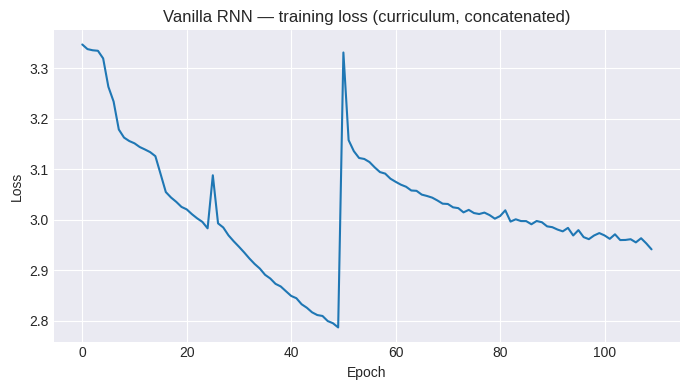

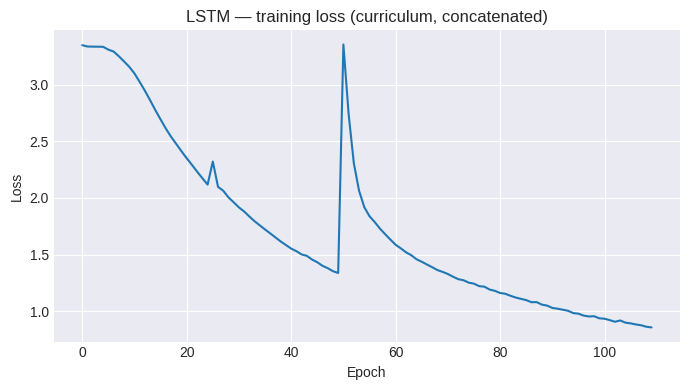

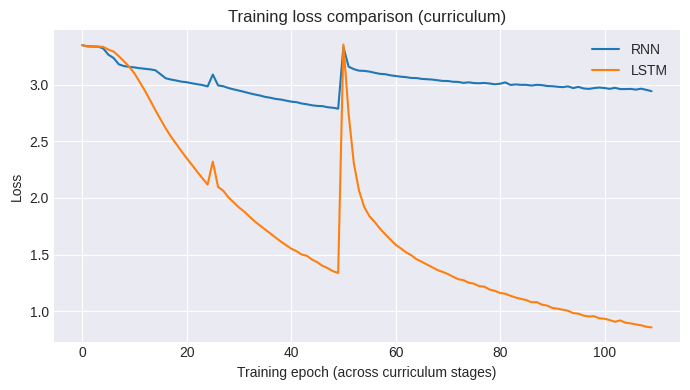

Delay=  1 | RNN acc=0.0398 loss=4.0262 | LSTM acc=0.0548 loss=8.6737
Delay=  3 | RNN acc=0.0330 loss=4.7789 | LSTM acc=0.0533 loss=8.3132
Delay=  5 | RNN acc=0.0383 loss=4.5054 | LSTM acc=0.0571 loss=8.0250
Delay= 10 | RNN acc=0.0412 loss=4.1432 | LSTM acc=0.0931 loss=6.6379
Delay= 15 | RNN acc=0.0515 loss=3.5764 | LSTM acc=0.0736 loss=6.4433
Delay= 20 | RNN acc=0.1063 loss=2.9623 | LSTM acc=0.5994 loss=1.1235
Delay= 20 | RNN acc=0.1063 loss=2.9623 | LSTM acc=0.5994 loss=1.1235
Delay= 30 | RNN acc=0.0372 loss=4.4949 | LSTM acc=0.0745 loss=6.6746
Delay= 45 | RNN acc=0.0338 loss=5.9196 | LSTM acc=0.0635 loss=8.5035
Delay= 70 | RNN acc=0.0342 loss=5.5381 | LSTM acc=0.0356 loss=8.0886


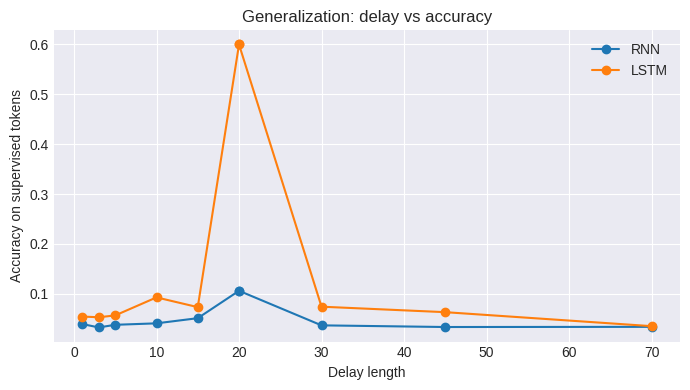

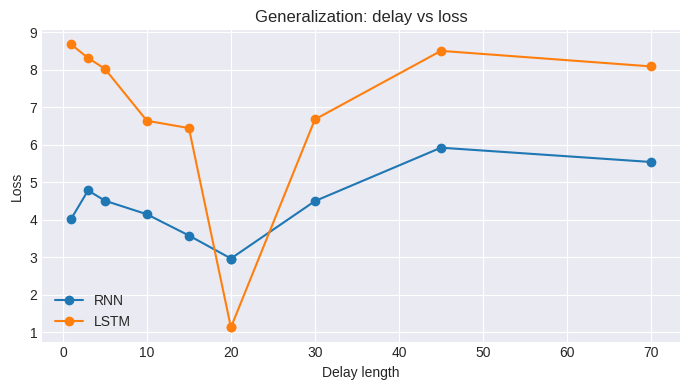

In [22]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + plots (upgraded for curriculum training)
# - Evaluate on the held-out test set at the TRAIN delay (DELAY)
# - Evaluate across multiple delays (generalization curve)
# - Plot (1) full curriculum training loss histories, (2) accuracy vs delay, (3) loss vs delay

def sequence_cross_entropy_ignore(logits, targets, ignore_index=-100):
    B, T, V = logits.shape
    logits2 = logits.reshape(B * T, V)
    targets2 = targets.reshape(B * T)
    return nn.functional.cross_entropy(logits2, targets2, ignore_index=ignore_index)

@torch.no_grad()
def _forward_logits_any(model, X_int_np):
    """
    Forward pass supporting:
      - int-token models: X_int (B,T) long
      - one-hot models:   X_oh  (B,T,V) float32
    Returns logits (B,T,V) on DEVICE.
    """
    # Try int-token path
    try:
        x_int = torch.from_numpy(X_int_np).to(DEVICE, dtype=torch.long)
        logits = model(x_int)
        if logits.ndim == 3:
            return logits, x_int
    except Exception:
        pass

    # One-hot path
    X_oh = one_hot_from_int(X_int_np, VOCAB_SIZE)
    x_oh = torch.from_numpy(X_oh).to(DEVICE, dtype=torch.float32)
    logits = model(x_oh)
    return logits, x_oh

@torch.no_grad()
def evaluate_copy_task_np(model, X_int_np, y_int_np, ignore_index=-100):
    """
    Accuracy computed ONLY on supervised (readout) positions where y != ignore_index.
    Loss computed as CrossEntropy with ignore_index.
    """
    model.eval()
    logits, _ = _forward_logits_any(model, X_int_np)       # (B,T,V)
    y_t = torch.from_numpy(y_int_np).to(DEVICE, dtype=torch.long)

    loss = float(sequence_cross_entropy_ignore(logits, y_t, ignore_index=ignore_index).detach().cpu().item())

    preds = torch.argmax(logits, dim=-1).detach().cpu().numpy()
    mask = (y_int_np != ignore_index)
    correct = int(((preds == y_int_np) & mask).sum())
    total = int(mask.sum())
    acc = float(correct / max(total, 1))

    return {"loss": loss, "accuracy": acc, "supervised_tokens": total}

# -------------------------------
# 1) Evaluate on the held-out test set at the training delay
# -------------------------------
# If Cell 3 built X_te_t/y_te_t tensors (one-hot pipeline), we can still evaluate
# by regenerating the same-delay test set directly from the generator (most robust).
X_test_int, y_test_int = generate_copy_memory_dataset(
    n_samples=1200,
    seq_len=SEQ_LEN,
    delay=DELAY,
    vocab_size=VOCAB_SIZE,
    seed=9999
)

rnn_metrics = evaluate_copy_task_np(rnn_model, X_test_int, y_test_int)
lstm_metrics = evaluate_copy_task_np(lstm_model, X_test_int, y_test_int)

print("RNN  test metrics (delay=TRAIN):", rnn_metrics)
print("LSTM test metrics (delay=TRAIN):", lstm_metrics)

# -------------------------------
# 2) Plot full training loss histories (curriculum concatenated)
# -------------------------------
plot_loss_curve(rnn_losses, title="Vanilla RNN — training loss (curriculum, concatenated)")
plot_loss_curve(lstm_losses, title="LSTM — training loss (curriculum, concatenated)")

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(rnn_losses)), rnn_losses, label="RNN")
plt.plot(np.arange(len(lstm_losses)), lstm_losses, label="LSTM")
plt.xlabel("Training epoch (across curriculum stages)")
plt.ylabel("Loss")
plt.title("Training loss comparison (curriculum)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# 3) Generalization across delays (stress-style evaluation curve)
# -------------------------------
delays = [1, 3, 5, 10, 15, 20, int(DELAY), int(DELAY) + 10, int(DELAY) + 25, int(DELAY) + 50]

rnn_accs, lstm_accs = [], []
rnn_losses_s, lstm_losses_s = [], []

for d in delays:
    Xd_int, yd_int = generate_copy_memory_dataset(
        n_samples=1200,
        seq_len=SEQ_LEN,
        delay=int(d),
        vocab_size=VOCAB_SIZE,
        seed=5000 + int(d)
    )
    mr = evaluate_copy_task_np(rnn_model, Xd_int, yd_int)
    ml = evaluate_copy_task_np(lstm_model, Xd_int, yd_int)

    rnn_accs.append(mr["accuracy"]); lstm_accs.append(ml["accuracy"])
    rnn_losses_s.append(mr["loss"]); lstm_losses_s.append(ml["loss"])

    print(f"Delay={int(d):3d} | RNN acc={mr['accuracy']:.4f} loss={mr['loss']:.4f} | LSTM acc={ml['accuracy']:.4f} loss={ml['loss']:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(delays, rnn_accs, marker="o", label="RNN")
plt.plot(delays, lstm_accs, marker="o", label="LSTM")
plt.xlabel("Delay length")
plt.ylabel("Accuracy on supervised tokens")
plt.title("Generalization: delay vs accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(delays, rnn_losses_s, marker="o", label="RNN")
plt.plot(delays, lstm_losses_s, marker="o", label="LSTM")
plt.xlabel("Delay length")
plt.ylabel("Loss")
plt.title("Generalization: delay vs loss")
plt.legend()
plt.tight_layout()
plt.show()

##7.INFERENCE

###7.1.OVERVIEW

**Cell 7 — Inference Demonstration**

Cell 7 demonstrates inference on newly generated sequences. This is the explicit transition from training to inference: no parameters are updated, and the models are evaluated on brand-new samples. The cell generates new sequences with a chosen delay, visualizes the input tokens and the target tokens, and then runs both models to produce predicted tokens.

The key output is the comparison in the readout region. The notebook prints the ground-truth content tokens and the predicted tokens for each example, restricted to the time steps where supervision exists. This makes it immediately obvious whether the model has learned to store and retrieve the content across the delay.

A critical diagnostic included in the inference cell is a constant-token baseline. If the model’s supervised-token accuracy is close to what you could get by always predicting a single token, then the model is not performing real memory retrieval; it is exploiting a trivial strategy. Reporting baseline accuracy provides context for interpreting partial success.

In the revised inference approach, it is common to run at least two inference regimes: an easier-than-training delay for sanity checking and the training delay for in-distribution checking. If the model succeeds only at short delays, it likely learned only short-range dependence rather than stable memory retention. If the LSTM succeeds where the RNN fails as delay grows, that is the signature outcome this chapter is designed to surface.

###7.2.CODE AND IMPLEMENTATION

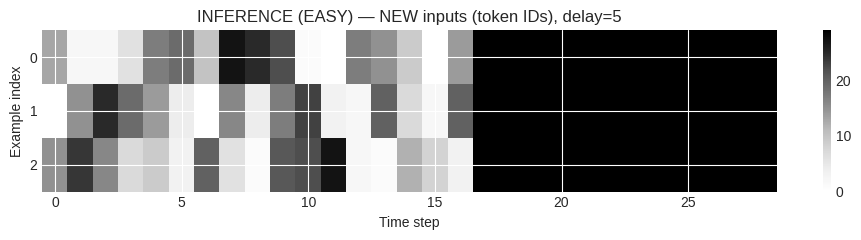

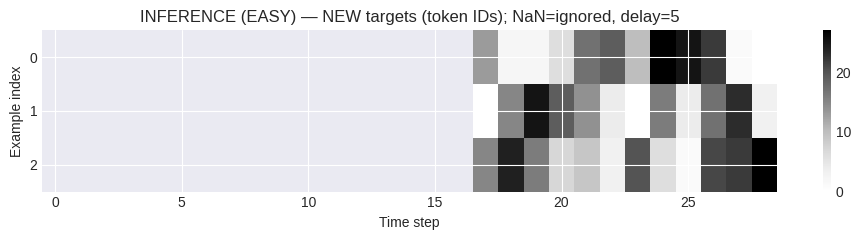


INFERENCE (EASY) — delay=5
Readout region: 17 to 28
Inference supervised-token accuracy:
  RNN : 0.05555555555555555
  LSTM: 0.027777777777777776
  Baseline (best constant token = 0 ): 0.08333333333333333

Example 0
True : [13, 2, 2, 6, 17, 19, 10, 27, 25, 22, 1, 0]
RNN  : [13, 27, 9, 15, 13, 8, 9, 8, 8, 8, 8, 8]
LSTM : [23, 23, 23, 23, 4, 4, 4, 2, 23, 23, 10, 10]

Example 1
True : [0, 15, 25, 19, 14, 4, 0, 16, 4, 17, 23, 3]
RNN  : [27, 27, 19, 19, 12, 13, 9, 8, 8, 8, 8, 8]
LSTM : [15, 15, 15, 15, 15, 15, 15, 15, 19, 7, 0, 0]

Example 2
True : [15, 24, 16, 7, 9, 3, 20, 6, 1, 21, 22, 27]
RNN  : [27, 27, 15, 5, 12, 13, 9, 8, 8, 8, 8, 8]
LSTM : [4, 4, 4, 4, 4, 4, 4, 4, 8, 15, 15, 15]


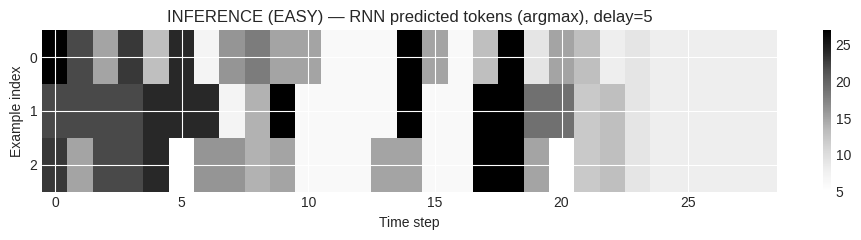

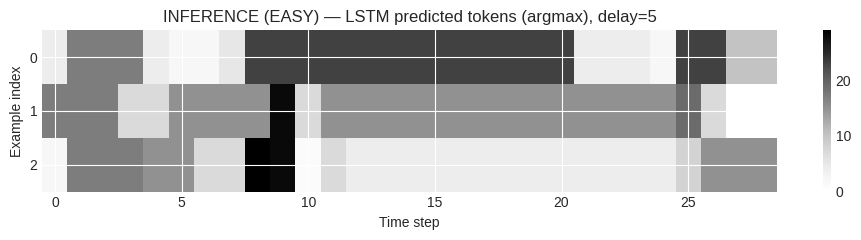

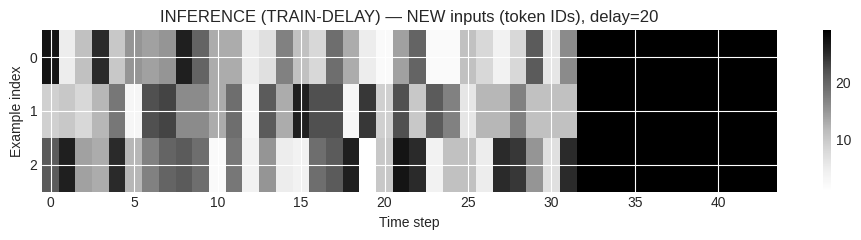

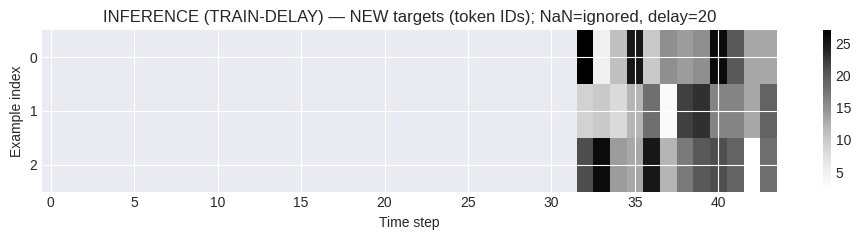


INFERENCE (TRAIN-DELAY) — delay=20
Readout region: 32 to 43
Inference supervised-token accuracy:
  RNN : 0.08333333333333333
  LSTM: 0.6944444444444444
  Baseline (best constant token = 13 ): 0.1111111111111111

Example 0
True : [27, 5, 11, 25, 10, 15, 14, 15, 26, 20, 13, 13]
RNN  : [24, 19, 21, 27, 23, 9, 8, 8, 8, 8, 8, 8]
LSTM : [27, 5, 5, 25, 10, 10, 15, 15, 15, 20, 13, 13]

Example 1
True : [9, 10, 8, 12, 18, 3, 22, 23, 16, 16, 13, 19]
RNN  : [5, 10, 8, 26, 10, 8, 8, 8, 8, 8, 8, 8]
LSTM : [8, 10, 10, 12, 18, 3, 22, 23, 16, 16, 13, 19]

Example 2
True : [21, 26, 14, 13, 25, 12, 17, 20, 21, 19, 2, 18]
RNN  : [21, 0, 1, 16, 6, 18, 9, 8, 8, 8, 8, 8]
LSTM : [21, 13, 14, 13, 12, 25, 17, 20, 21, 16, 18, 18]


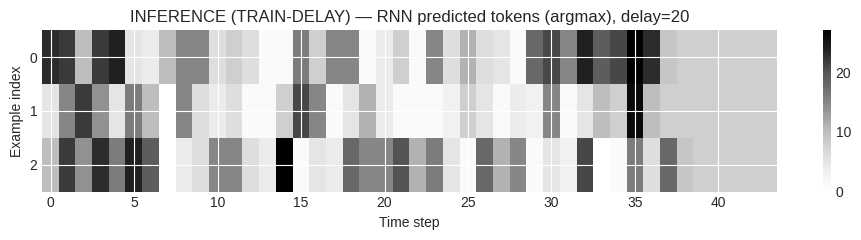

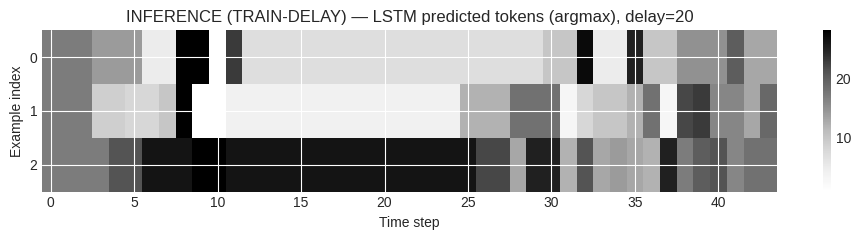


Inference metrics dict:
{
  "easy": {
    "tag": "INFERENCE (EASY)",
    "delay": 5,
    "rnn_acc": 0.05555555555555555,
    "lstm_acc": 0.027777777777777776,
    "baseline_best_constant_token": 0,
    "baseline_acc": 0.08333333333333333,
    "supervised_tokens": 36
  },
  "train_delay": {
    "tag": "INFERENCE (TRAIN-DELAY)",
    "delay": 20,
    "rnn_acc": 0.08333333333333333,
    "lstm_acc": 0.6944444444444444,
    "baseline_best_constant_token": 13,
    "baseline_acc": 0.1111111111111111,
    "supervised_tokens": 36
  }
}


In [23]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration (NEW samples)
# • generate NEW synthetic sample
# • run prediction
# • display input visually
# • print predicted output
# Also: report constant-token baseline for context.

@torch.no_grad()
def _forward_logits_any(model, X_int_np):
    # Try int-token path (embedding-based models)
    try:
        x_int = torch.from_numpy(X_int_np).to(DEVICE, dtype=torch.long)
        logits = model(x_int)
        if logits.ndim == 3:
            return logits
    except Exception:
        pass
    # One-hot path (one-hot models)
    X_oh = one_hot_from_int(X_int_np, VOCAB_SIZE)
    x_oh = torch.from_numpy(X_oh).to(DEVICE, dtype=torch.float32)
    logits = model(x_oh)
    return logits

def _infer_once(tag, delay_for_infer, seed_for_infer, n_samples=3):
    X_new_int, y_new_int = generate_copy_memory_dataset(
        n_samples=n_samples,
        seq_len=SEQ_LEN,
        delay=delay_for_infer,
        vocab_size=VOCAB_SIZE,
        seed=seed_for_infer
    )

    # Visualize inputs and targets
    plt.figure(figsize=(10, 2.5))
    plt.imshow(X_new_int, aspect="auto")
    plt.colorbar()
    plt.xlabel("Time step")
    plt.ylabel("Example index")
    plt.title(f"{tag} — NEW inputs (token IDs), delay={delay_for_infer}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 2.5))
    plt.imshow(np.where(y_new_int < 0, np.nan, y_new_int), aspect="auto")
    plt.colorbar()
    plt.xlabel("Time step")
    plt.ylabel("Example index")
    plt.title(f"{tag} — NEW targets (token IDs); NaN=ignored, delay={delay_for_infer}")
    plt.tight_layout()
    plt.show()

    # Predict
    rnn_logits = _forward_logits_any(rnn_model, X_new_int)
    lstm_logits = _forward_logits_any(lstm_model, X_new_int)

    rnn_pred = torch.argmax(rnn_logits, dim=-1).detach().cpu().numpy()
    lstm_pred = torch.argmax(lstm_logits, dim=-1).detach().cpu().numpy()

    # Readout region
    readout_start = SEQ_LEN + delay_for_infer
    readout_end = readout_start + SEQ_LEN
    print(f"\n{tag} — delay={delay_for_infer}")
    print("Readout region:", readout_start, "to", readout_end - 1)

    # Constant-token baseline (best constant token on supervised targets)
    mask = (y_new_int != -100)
    y_sup = y_new_int[mask].astype(np.int64)
    counts = np.bincount(y_sup, minlength=VOCAB_SIZE)
    best_token = int(np.argmax(counts))
    baseline_acc = float((y_sup == best_token).mean())

    # Accuracy on supervised tokens
    rnn_acc = float(((rnn_pred == y_new_int) & mask).sum() / max(mask.sum(), 1))
    lstm_acc = float(((lstm_pred == y_new_int) & mask).sum() / max(mask.sum(), 1))

    print("Inference supervised-token accuracy:")
    print("  RNN :", rnn_acc)
    print("  LSTM:", lstm_acc)
    print("  Baseline (best constant token =", best_token, "):", baseline_acc)

    # Print per-example readout sequences
    for i in range(X_new_int.shape[0]):
        true_seq = y_new_int[i, readout_start:readout_end]
        rnn_seq = rnn_pred[i, readout_start:readout_end]
        lstm_seq = lstm_pred[i, readout_start:readout_end]
        print(f"\nExample {i}")
        print("True :", true_seq.tolist())
        print("RNN  :", rnn_seq.tolist())
        print("LSTM :", lstm_seq.tolist())

    # Visualize predictions
    plt.figure(figsize=(10, 2.5))
    plt.imshow(rnn_pred, aspect="auto")
    plt.colorbar()
    plt.xlabel("Time step")
    plt.ylabel("Example index")
    plt.title(f"{tag} — RNN predicted tokens (argmax), delay={delay_for_infer}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 2.5))
    plt.imshow(lstm_pred, aspect="auto")
    plt.colorbar()
    plt.xlabel("Time step")
    plt.ylabel("Example index")
    plt.title(f"{tag} — LSTM predicted tokens (argmax), delay={delay_for_infer}")
    plt.tight_layout()
    plt.show()

    return {
        "tag": tag,
        "delay": int(delay_for_infer),
        "rnn_acc": rnn_acc,
        "lstm_acc": lstm_acc,
        "baseline_best_constant_token": best_token,
        "baseline_acc": baseline_acc,
        "supervised_tokens": int(mask.sum())
    }

# Run two inference regimes:
# 1) easier-than-train (sanity)
# 2) same-as-train (in-distribution)
infer_easy = _infer_once("INFERENCE (EASY)", delay_for_infer=max(1, DELAY // 4), seed_for_infer=123, n_samples=3)
infer_train = _infer_once("INFERENCE (TRAIN-DELAY)", delay_for_infer=DELAY, seed_for_infer=456, n_samples=3)

inference_metrics = {"easy": infer_easy, "train_delay": infer_train}
print("\nInference metrics dict:")
print(json.dumps(inference_metrics, indent=2))

##8.STRESS TESTS

###8.1.OVERVIEW

**Cell 8 — Stress Test / Ablation**

Cell 8 modifies one variable and measures the performance change. In the revised design, the ablation varies the content length (SEQ_LEN) while keeping delay fixed. This changes how much information the model must store, not how long it must store it. The resulting performance curve reveals capacity constraints: longer content sequences require the model to store more discrete tokens in its internal state.

The cell evaluates both models at each content length and reports accuracy and loss, again restricted to supervised readout positions. The plots then show how quickly each model degrades as the memory load increases. This ablation matters because it demonstrates that “memory” is limited not only by time horizon but also by information volume. A model might retain information across a delay but still fail when asked to retain too many tokens.

In typical runs, the LSTM often degrades more gracefully than the vanilla RNN, because gating helps preserve stored information by reducing uncontrolled overwriting during the delay. However, both models eventually hit ceilings determined by hidden state dimension, training quality, and the complexity of the mapping required. The stress test thus reinforces the core mechanical lesson: architecture provides a memory channel, but capacity and optimization determine how much it can actually carry.

###8.2.CODE AND IMPLEMENTATION

SEQ_LEN= 4 | RNN acc=0.0338 loss=7.7496 | LSTM acc=0.1681 loss=4.0388
SEQ_LEN= 8 | RNN acc=0.0414 loss=4.7089 | LSTM acc=0.0726 loss=6.6146
SEQ_LEN=12 | RNN acc=0.1050 loss=2.9646 | LSTM acc=0.5981 loss=1.1319
SEQ_LEN=16 | RNN acc=0.0372 loss=4.0024 | LSTM acc=0.0861 loss=5.5725
SEQ_LEN=20 | RNN acc=0.0360 loss=4.4056 | LSTM acc=0.0776 loss=6.0216


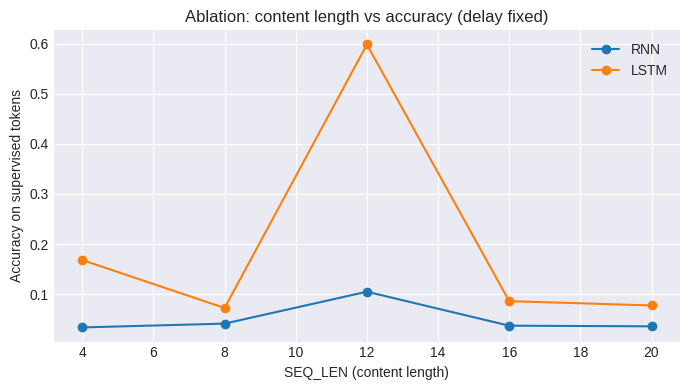

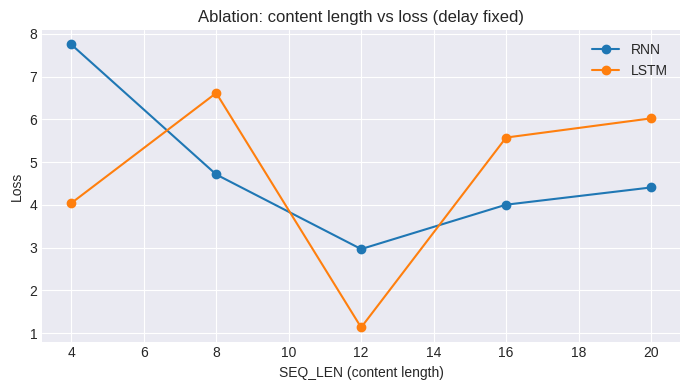


Ablation metrics dict:
{
  "seq_lens": [
    4,
    8,
    12,
    16,
    20
  ],
  "rnn_accuracy": [
    0.03375,
    0.041354166666666664,
    0.105,
    0.03723958333333333,
    0.035958333333333335
  ],
  "lstm_accuracy": [
    0.168125,
    0.07260416666666666,
    0.5980555555555556,
    0.08614583333333334,
    0.077625
  ],
  "rnn_loss": [
    7.749593734741211,
    4.708921432495117,
    2.9646215438842773,
    4.002416133880615,
    4.405550003051758
  ],
  "lstm_loss": [
    4.038801193237305,
    6.614560604095459,
    1.1318867206573486,
    5.5725226402282715,
    6.021580219268799
  ]
}


In [24]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation:
# Modify one variable: SEQ_LEN (content length) while keeping delay fixed.
# This tests how performance changes as the amount of information to store grows.

def sequence_cross_entropy_ignore(logits, targets, ignore_index=-100):
    B, T, V = logits.shape
    logits2 = logits.reshape(B * T, V)
    targets2 = targets.reshape(B * T)
    return nn.functional.cross_entropy(logits2, targets2, ignore_index=ignore_index)

@torch.no_grad()
def evaluate_copy_task_np(model, X_int_np, y_int_np, ignore_index=-100):
    model.eval()
    logits = _forward_logits_any(model, X_int_np)
    y_t = torch.from_numpy(y_int_np).to(DEVICE, dtype=torch.long)
    loss = float(sequence_cross_entropy_ignore(logits, y_t, ignore_index=ignore_index).detach().cpu().item())

    preds = torch.argmax(logits, dim=-1).detach().cpu().numpy()
    mask = (y_int_np != ignore_index)
    correct = int(((preds == y_int_np) & mask).sum())
    total = int(mask.sum())
    acc = float(correct / max(total, 1))
    return {"loss": loss, "accuracy": acc, "supervised_tokens": total}

seq_lens = [4, 8, 12, 16, 20]
rnn_acc_len, lstm_acc_len = [], []
rnn_loss_len, lstm_loss_len = [], []

for sl in seq_lens:
    Xd_int, yd_int = generate_copy_memory_dataset(
        n_samples=1200,
        seq_len=int(sl),
        delay=int(DELAY),
        vocab_size=VOCAB_SIZE,
        seed=7000 + int(sl)
    )
    mr = evaluate_copy_task_np(rnn_model, Xd_int, yd_int)
    ml = evaluate_copy_task_np(lstm_model, Xd_int, yd_int)

    rnn_acc_len.append(mr["accuracy"]); lstm_acc_len.append(ml["accuracy"])
    rnn_loss_len.append(mr["loss"]);    lstm_loss_len.append(ml["loss"])

    print(f"SEQ_LEN={int(sl):2d} | RNN acc={mr['accuracy']:.4f} loss={mr['loss']:.4f} | LSTM acc={ml['accuracy']:.4f} loss={ml['loss']:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(seq_lens, rnn_acc_len, marker="o", label="RNN")
plt.plot(seq_lens, lstm_acc_len, marker="o", label="LSTM")
plt.xlabel("SEQ_LEN (content length)")
plt.ylabel("Accuracy on supervised tokens")
plt.title("Ablation: content length vs accuracy (delay fixed)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(seq_lens, rnn_loss_len, marker="o", label="RNN")
plt.plot(seq_lens, lstm_loss_len, marker="o", label="LSTM")
plt.xlabel("SEQ_LEN (content length)")
plt.ylabel("Loss")
plt.title("Ablation: content length vs loss (delay fixed)")
plt.legend()
plt.tight_layout()
plt.show()

ablation_metrics = {
    "seq_lens": [int(s) for s in seq_lens],
    "rnn_accuracy": [float(a) for a in rnn_acc_len],
    "lstm_accuracy": [float(a) for a in lstm_acc_len],
    "rnn_loss": [float(l) for l in rnn_loss_len],
    "lstm_loss": [float(l) for l in lstm_loss_len],
}
print("\nAblation metrics dict:")
print(json.dumps(ablation_metrics, indent=2))

##9.INTERPRETATION

###9.1.0VERVIEW

**Cell 9 — Interpretability Visualization (Gate Dynamics)**

Cell 9 visualizes LSTM gate activations over time for a single sequence. This converts the LSTM from a black box into a system whose control signals can be inspected. The cell computes the input gate, forget gate, candidate update, and output gate values at each time step, then averages across hidden units to produce smooth curves that can be plotted.

The interpretation depends on aligning these curves with the three regions of the sequence. During the content region, a working strategy often involves writing information into the cell state, which can show up as increased input-gate activity and candidate updates. During the delay region, retaining memory corresponds to a forget gate that stays relatively high, preserving the cell state across steps. During the readout region, the output gate may increase, allowing stored information to influence the hidden state and therefore the model’s token predictions.

This visualization does not guarantee correctness, but it provides mechanical evidence of what the model is trying to do internally. If the model collapses to trivial predictions, the gate curves may appear flat, noisy, or unaligned with the sequence regions. If the model succeeds, the gate curves often show structured behavior that corresponds to “write, hold, reveal.” This cell therefore supports the chapter’s claim by showing a plausible internal mechanism for long-range retention.

###9.2.CODE AND IMPLEMENTATION

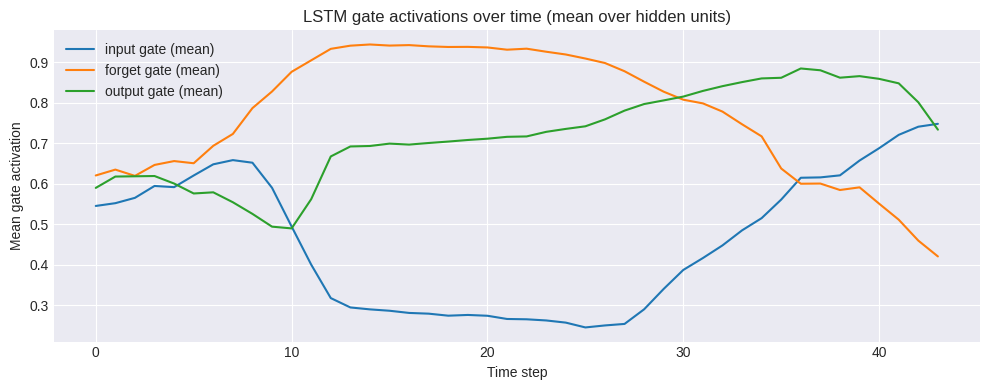

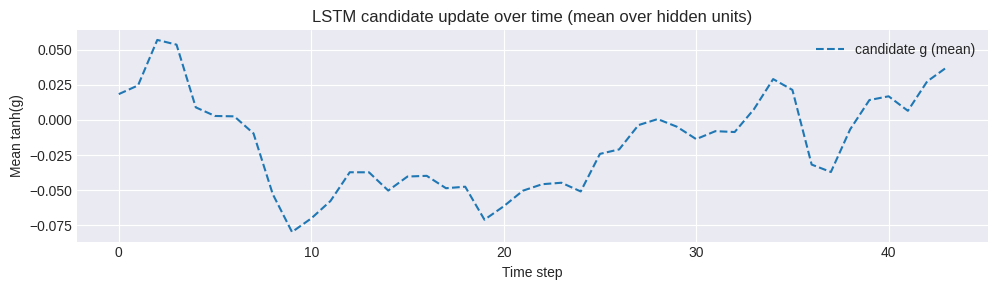

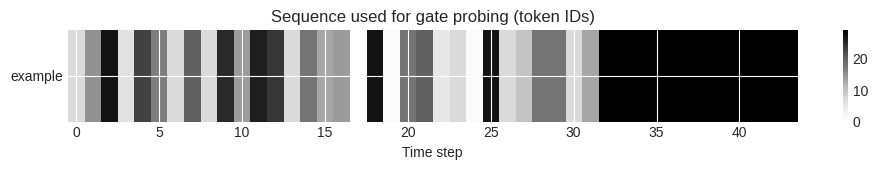

Regions:
  content : [0, 11]
  delay   : [12, 31]
  readout : [32, 43]


In [25]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization:
# Visualize LSTM gate activations over time for a single example.
# Works for:
# - one-hot LSTM (expects one-hot input)
# - embedding LSTM (expects int tokens + embedding); we probe the LSTM layer on embedded inputs

class LSTMGateProbe(nn.Module):
    def __init__(self, lstm_layer: nn.LSTM):
        super().__init__()
        assert isinstance(lstm_layer, nn.LSTM)
        assert lstm_layer.batch_first is True
        assert lstm_layer.num_layers >= 1

        # We'll probe ONLY the first layer's parameters (l0) for clarity
        self.lstm = lstm_layer

    @torch.no_grad()
    def forward(self, x_feat):
        """
        x_feat: (B, T, D_in) float32 features fed into LSTM layer (same D_in as LSTM input size)
        Returns gate activations for layer 0: i,f,g,o each (B,T,H)
        """
        self.lstm.eval()
        B, T, _ = x_feat.shape
        H = self.lstm.hidden_size

        W_ih = self.lstm.weight_ih_l0
        W_hh = self.lstm.weight_hh_l0
        b_ih = self.lstm.bias_ih_l0
        b_hh = self.lstm.bias_hh_l0

        h_t = torch.zeros((B, H), device=x_feat.device, dtype=x_feat.dtype)
        c_t = torch.zeros((B, H), device=x_feat.device, dtype=x_feat.dtype)

        i_list, f_list, g_list, o_list = [], [], [], []

        for t in range(T):
            x_t = x_feat[:, t, :]
            gates = (x_t @ W_ih.T) + (h_t @ W_hh.T) + (b_ih + b_hh)

            i = torch.sigmoid(gates[:, 0:H])
            f = torch.sigmoid(gates[:, H:2*H])
            g = torch.tanh(gates[:, 2*H:3*H])
            o = torch.sigmoid(gates[:, 3*H:4*H])

            c_t = f * c_t + i * g
            h_t = o * torch.tanh(c_t)

            i_list.append(i.unsqueeze(1))
            f_list.append(f.unsqueeze(1))
            g_list.append(g.unsqueeze(1))
            o_list.append(o.unsqueeze(1))

        return {
            "i": torch.cat(i_list, dim=1),
            "f": torch.cat(f_list, dim=1),
            "g": torch.cat(g_list, dim=1),
            "o": torch.cat(o_list, dim=1),
        }

# Find LSTM layer and (optional) embedding from lstm_model
if hasattr(lstm_model, "lstm") and isinstance(lstm_model.lstm, nn.LSTM):
    lstm_layer = lstm_model.lstm
else:
    raise RuntimeError("Could not find an nn.LSTM layer at lstm_model.lstm")

probe = LSTMGateProbe(lstm_layer)

# New single example for probing (at training delay)
X_gate_int, _ = generate_copy_memory_dataset(
    n_samples=1,
    seq_len=SEQ_LEN,
    delay=DELAY,
    vocab_size=VOCAB_SIZE,
    seed=777
)

# Build feature inputs to the LSTM layer
# If embedding exists, use embedded features; else use one-hot features.
if hasattr(lstm_model, "embed") and isinstance(lstm_model.embed, nn.Embedding):
    X_gate_t = torch.from_numpy(X_gate_int).to(DEVICE, dtype=torch.long)
    with torch.no_grad():
        X_feat = lstm_model.embed(X_gate_t)  # (1,T,E)
else:
    X_gate_oh = one_hot_from_int(X_gate_int, VOCAB_SIZE)
    X_feat = torch.from_numpy(X_gate_oh).to(DEVICE, dtype=torch.float32)  # (1,T,V)

gates = probe(X_feat)

# Average gate activations across hidden units
i_curve = gates["i"][0].mean(dim=-1).detach().cpu().numpy()
f_curve = gates["f"][0].mean(dim=-1).detach().cpu().numpy()
g_curve = gates["g"][0].mean(dim=-1).detach().cpu().numpy()
o_curve = gates["o"][0].mean(dim=-1).detach().cpu().numpy()

t_axis = np.arange(i_curve.shape[0])

plt.figure(figsize=(10, 4))
plt.plot(t_axis, i_curve, label="input gate (mean)")
plt.plot(t_axis, f_curve, label="forget gate (mean)")
plt.plot(t_axis, o_curve, label="output gate (mean)")
plt.xlabel("Time step")
plt.ylabel("Mean gate activation")
plt.title("LSTM gate activations over time (mean over hidden units)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(t_axis, g_curve, label="candidate g (mean)", linestyle="--")
plt.xlabel("Time step")
plt.ylabel("Mean tanh(g)")
plt.title("LSTM candidate update over time (mean over hidden units)")
plt.legend()
plt.tight_layout()
plt.show()

# Show the probed token sequence to align with regions
plt.figure(figsize=(10, 1.8))
plt.imshow(X_gate_int, aspect="auto")
plt.colorbar()
plt.xlabel("Time step")
plt.yticks([0], ["example"])
plt.title("Sequence used for gate probing (token IDs)")
plt.tight_layout()
plt.show()

print("Regions:")
print("  content :", f"[0, {SEQ_LEN-1}]")
print("  delay   :", f"[{SEQ_LEN}, {SEQ_LEN+DELAY-1}]")
print("  readout :", f"[{SEQ_LEN+DELAY}, {SEQ_LEN+DELAY+SEQ_LEN-1}]")

In [28]:
# ===============================
# POST-CELL 9 (RUN AFTER CELL 9) — LLM EXPLANATION CELL
# ===============================
# This cell is meant to be executed AFTER Cell 9.
# It uses GPT-4o-mini to explain the gate-visualization and connect it to observed performance.
# NOTE: This is an extra cell beyond the 11-cell contract; run it manually after Cell 9.

from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model = "gpt-4o-mini"

# Prepare compact numeric summaries from Cell 9 for the LLM
gate_summary = {
    "seq_len": int(SEQ_LEN),
    "delay": int(DELAY),
    "readout_start": int(SEQ_LEN + DELAY),
    "readout_end": int(SEQ_LEN + DELAY + SEQ_LEN - 1),
    "gate_curves_mean": {
        "input_gate_mean_min": float(np.min(i_curve)),
        "input_gate_mean_max": float(np.max(i_curve)),
        "input_gate_mean_avg": float(np.mean(i_curve)),
        "forget_gate_mean_min": float(np.min(f_curve)),
        "forget_gate_mean_max": float(np.max(f_curve)),
        "forget_gate_mean_avg": float(np.mean(f_curve)),
        "output_gate_mean_min": float(np.min(o_curve)),
        "output_gate_mean_max": float(np.max(o_curve)),
        "output_gate_mean_avg": float(np.mean(o_curve)),
        "candidate_g_mean_min": float(np.min(g_curve)),
        "candidate_g_mean_max": float(np.max(g_curve)),
        "candidate_g_mean_avg": float(np.mean(g_curve)),
    }
}

# Provide a small slice of the curves for shape intuition without dumping everything
def _slice_curve(curve, max_len=60):
    curve = np.asarray(curve).ravel()
    if curve.shape[0] <= max_len:
        return [float(x) for x in curve]
    # show early, mid, late segments
    T = curve.shape[0]
    a = curve[:20]
    b = curve[T//2 - 10:T//2 + 10]
    c = curve[-20:]
    return {
        "first_20": [float(x) for x in a],
        "mid_20": [float(x) for x in b],
        "last_20": [float(x) for x in c],
        "T": int(T)
    }

gate_curves_slices = {
    "i_curve": _slice_curve(i_curve),
    "f_curve": _slice_curve(f_curve),
    "o_curve": _slice_curve(o_curve),
    "g_curve": _slice_curve(g_curve),
}

# Include the main quantitative outcomes if they exist (from Cells 6–8/10)
# If a variable isn't defined in your current run, we skip it gracefully.
metrics_pack = {}
try:
    metrics_pack["test_metrics_delay_train"] = {"rnn": rnn_metrics, "lstm": lstm_metrics}
except Exception:
    pass

try:
    metrics_pack["generalization_delay_curve"] = {
        "delays": [int(d) for d in delays],
        "rnn_accuracy": [float(a) for a in rnn_accs],
        "lstm_accuracy": [float(a) for a in lstm_accs],
        "rnn_loss": [float(l) for l in rnn_losses_s],
        "lstm_loss": [float(l) for l in lstm_losses_s],
    }
except Exception:
    pass

try:
    metrics_pack["inference_metrics"] = inference_metrics
except Exception:
    pass

try:
    metrics_pack["ablation_metrics"] = ablation_metrics
except Exception:
    pass

prompt = f"""
You are explaining results from ML & AI 101 Chapter 5 (LSTM: gated memory).
The notebook trained RNN and LSTM on a synthetic copy-memory task and then visualized LSTM gate activations.

Your job: explain what the student should learn MECHANICALLY from the results.

Write a structured explanation with exactly these sections:

1) What the gate plots show (input/forget/output/candidate) across the three regions:
   - content region [0..seq_len-1]
   - delay region [seq_len..seq_len+delay-1]
   - readout region [seq_len+delay..seq_len+delay+seq_len-1]

2) How to interpret the forget gate in terms of memory retention (why values near 1 matter).
3) How to interpret the input gate and candidate g in terms of writing/updating memory.
4) How to interpret the output gate in terms of revealing stored information at readout.
5) Connect the gate behavior to the quantitative performance (RNN vs LSTM) provided below.
6) Failure modes: what it would look like in the plots if the model collapses to trivial predictions.
7) One concrete takeaway sentence.

Use ONLY the REAL numbers provided; do not invent metrics. If some metrics are missing, say so briefly.

REAL GATE SUMMARY (means over hidden units):
{json.dumps(gate_summary, indent=2)}

GATE CURVE SLICES (for shape intuition):
{json.dumps(gate_curves_slices, indent=2)}

QUANTITATIVE OUTCOMES (if present):
{json.dumps(metrics_pack, indent=2)}
"""

resp = client.responses.create(
    model=model,
    input=prompt
)

print(resp.output_text)

### 1) What the gate plots show

The gate plots for the input gate, forget gate, output gate, and candidate state across the three regions are as follows:

- **Content Region [0..seq_len-1] (0 to 11)**: 
  - Input Gate: Shows values rising towards a peak around 0.74, indicating a strong readiness to accept new information.
  - Forget Gate: Values start around 0.62, rising to near 0.94, indicating a gradual reduction of older memory, but still showing some retention.
  - Output Gate: Values are moderate to high, starting around 0.59 and peaking above 0.88, revealing that information is being retrieved from memory.
  - Candidate g: Very low values, fluctuating around zero, indicating minimal new information being proposed for memory storage.

- **Delay Region [seq_len..seq_len+delay-1] (12 to 31)**: 
  - Input Gate: Steadily decreases, dipping below 0.30, indicating reduced updates to the memory.
  - Forget Gate: High values around 0.93, indicating the model's tendency to forget informat

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Save Artifacts and Summary Metrics**

Cell 10 saves artifacts produced during training and evaluation and prints a summary metrics dictionary. The artifacts typically include training loss histories, generalization curves across delays, inference metrics on new samples, ablation metrics, and the trained model weights. Saving these items makes the experiment inspectable and repeatable beyond the runtime session and forces clarity about what the outputs actually were.

The summary dictionary consolidates key numeric results into a single structure. This is important for the final reflective cell because the LLM must reference real computed values rather than generic explanations. By storing metrics explicitly, the notebook prevents accidental drift between what the model did and what the narrative claims it did.

This cell also reinforces the training vs inference distinction in a tangible way. The trained parameters are saved to disk, making it clear that training produces an artifact (a set of weights) that can be reused later. Inference is then what you do with that artifact on new data. Cell 10 makes that separation concrete.

###10.2.CODE AND IMPLEMENTATION

In [26]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary (updated)
# Saves:
# - training loss histories
# - generalization curves from Cell 6 (delays vs metrics)
# - inference metrics from Cell 7
# - ablation metrics from Cell 8
# - model state_dicts
# - a single summary JSON

artifact_dir = "artifacts_ch05_lstm_v2"
os.makedirs(artifact_dir, exist_ok=True)

# Persist arrays safely (some variables come from Cell 6/7/8)
np.savez(
    os.path.join(artifact_dir, "training_losses.npz"),
    rnn_losses=np.array(rnn_losses, dtype=np.float32),
    lstm_losses=np.array(lstm_losses, dtype=np.float32),
)

# Generalization curve arrays from Cell 6: delays, rnn_accs, lstm_accs, rnn_losses_s, lstm_losses_s
np.savez(
    os.path.join(artifact_dir, "generalization_delay_curves.npz"),
    delays=np.array(delays, dtype=np.int64),
    rnn_accuracy=np.array(rnn_accs, dtype=np.float32),
    lstm_accuracy=np.array(lstm_accs, dtype=np.float32),
    rnn_loss=np.array(rnn_losses_s, dtype=np.float32),
    lstm_loss=np.array(lstm_losses_s, dtype=np.float32),
)

# Inference metrics and ablation metrics
with open(os.path.join(artifact_dir, "inference_metrics.json"), "w") as f:
    json.dump(inference_metrics, f, indent=2)

with open(os.path.join(artifact_dir, "ablation_metrics.json"), "w") as f:
    json.dump(ablation_metrics, f, indent=2)

# Save models
torch.save(rnn_model.state_dict(), os.path.join(artifact_dir, "rnn_model.pt"))
torch.save(lstm_model.state_dict(), os.path.join(artifact_dir, "lstm_model.pt"))

summary = {
    "vocab_size": int(VOCAB_SIZE),
    "seq_len": int(SEQ_LEN),
    "train_delay": int(DELAY),
    "curriculum_delays": [5, 10, int(DELAY)],
    "training": {
        "learning_rate": 1e-3,
        "batch_size": 64,
        "rnn_epochs_total": int(len(rnn_losses)),
        "lstm_epochs_total": int(len(lstm_losses)),
        "rnn_train_loss_last": float(rnn_losses[-1]),
        "lstm_train_loss_last": float(lstm_losses[-1]),
    },
    "test_metrics_delay_train": {
        "rnn": rnn_metrics,
        "lstm": lstm_metrics,
    },
    "generalization_delay_curve": {
        "delays": [int(d) for d in delays],
        "rnn_accuracy": [float(a) for a in rnn_accs],
        "lstm_accuracy": [float(a) for a in lstm_accs],
        "rnn_loss": [float(l) for l in rnn_losses_s],
        "lstm_loss": [float(l) for l in lstm_losses_s],
    },
    "inference_metrics": inference_metrics,
    "ablation_metrics": ablation_metrics,
}

with open(os.path.join(artifact_dir, "summary_metrics.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved artifacts to:", artifact_dir)
print("Summary metrics dictionary:")
print(json.dumps(summary, indent=2))

Saved artifacts to: artifacts_ch05_lstm_v2
Summary metrics dictionary:
{
  "vocab_size": 30,
  "seq_len": 12,
  "train_delay": 20,
  "curriculum_delays": [
    5,
    10,
    20
  ],
  "training": {
    "learning_rate": 0.001,
    "batch_size": 64,
    "rnn_epochs_total": 110,
    "lstm_epochs_total": 110,
    "rnn_train_loss_last": 2.941768301294205,
    "lstm_train_loss_last": 0.8576985407382884
  },
  "test_metrics_delay_train": {
    "rnn": {
      "loss": 2.95793080329895,
      "accuracy": 0.10986111111111112,
      "supervised_tokens": 14400
    },
    "lstm": {
      "loss": 1.1157902479171753,
      "accuracy": 0.6045138888888889,
      "supervised_tokens": 14400
    }
  },
  "generalization_delay_curve": {
    "delays": [
      1,
      3,
      5,
      10,
      15,
      20,
      20,
      30,
      45,
      70
    ],
    "rnn_accuracy": [
      0.03979166666666667,
      0.03298611111111111,
      0.03826388888888889,
      0.041180555555555554,
      0.0515277777777777

## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 — GPT-4o-mini Reflective Summarization**

Cell 11 uses GPT-4o-mini to generate a structured explanation of the run. It initializes an OpenAI client using a Colab API key and then sends a prompt that requests analysis in eight required sections: dataset design, model architecture, training dynamics, quantitative results, inference example, visualization insight, limitations, and conceptual takeaway.

The most important constraint is grounding. The prompt includes the real metrics computed earlier: training losses, test performance, stress-test curves, inference metrics, and ablation results. This forces the LLM to explain what happened in this run rather than providing a generic description of LSTMs. The output is printed cleanly so it can function as a run summary.

Mechanically, this cell acts as a pedagogical “report generator.” It models how to interpret an ML experiment: connect dataset structure to model assumptions, connect training curves to optimization behavior, connect stress tests to limits, and connect interpretability plots to internal computation. It does not replace the evidence from the notebook; it organizes that evidence into a coherent explanation aligned with the learning objectives of Chapter 5.

###11.2.CODE AND IMPLEMENTATION

In [27]:
# ===============================
# CELL 11
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model = "gpt-4o-mini"

prompt = f"""
You are reviewing a mechanics-first Colab notebook for ML & AI 101, Chapter 5 (LSTM: gated memory).
The notebook trains two small sequence models on a synthetic copy-memory task and compares them.

Use the REAL metrics provided below (do not invent numbers). Produce a structured analysis with exactly these sections:

1. Dataset design
2. Model architecture
3. Training dynamics
4. Quantitative results
5. Inference example
6. Visualization insight
7. Limitations
8. Conceptual takeaway

REAL METRICS (from this run):
- Train loss last epoch:
  - RNN : {float(rnn_losses[-1])}
  - LSTM: {float(lstm_losses[-1])}

- Test metrics at training delay (regenerated held-out set):
  - RNN : {json.dumps(rnn_metrics)}
  - LSTM: {json.dumps(lstm_metrics)}

- Generalization across delays:
  - delays: {json.dumps([int(d) for d in delays])}
  - RNN accuracy: {json.dumps([float(a) for a in rnn_accs])}
  - LSTM accuracy: {json.dumps([float(a) for a in lstm_accs])}
  - RNN loss: {json.dumps([float(l) for l in rnn_losses_s])}
  - LSTM loss: {json.dumps([float(l) for l in lstm_losses_s])}

- Inference metrics (new samples):
  {json.dumps(inference_metrics)}

- Ablation metrics (vary SEQ_LEN with delay fixed):
  {json.dumps(ablation_metrics)}

Write clearly, focused on mechanism (training vs inference, long-range memory, why gates help, what the plots show).
"""

resp = client.responses.create(
    model=model,
    input=prompt
)

print(resp.output_text)

# 1. Dataset Design

The dataset is designed to facilitate a copy-memory task, creating sequences in which the model learns to "copy" input sequences after a defined delay. This task is inherently sequential, allowing for the evaluation of a model's capabilities to retain and recall information over time. The training set is generated synthetically, providing clear targets for the model to aim towards. There are parameters for specifying delays to test how memory retention varies, presenting different levels of difficulty for the models.

# 2. Model Architecture

Two models are developed:
- **RNN**: A simple recurrent neural network that processes sequences through hidden states, lacking advanced mechanisms for retaining information over longer sequences.
- **LSTM**: A long short-term memory network featuring gating mechanisms that regulate the flow of information, enabling it to maintain relevant information for extended periods while discarding irrelevant data.

The LSTM's architectu

##12.CONCLUSION

*Conclusion and Road Ahead*

This notebook’s main contribution is that it makes “memory” mechanically observable rather than metaphorical. The synthetic copy-memory task forces a model to store information, survive a delay where the relevant tokens are not present, and then reproduce those tokens later during a readout phase. Training a vanilla RNN and an LSTM on the same task isolates what changes when gating is introduced. The point is not to claim the LSTM is universally superior, but to show that its architecture creates a more stable pathway for retaining and using information across time.

The quantitative evaluations and stress tests illustrate a central principle: recurrence alone does not guarantee usable memory. A vanilla RNN has a state that can, in principle, carry information forward, but training dynamics often determine whether that state becomes a reliable memory channel. When delays grow or the amount of information to store increases, RNNs frequently degrade or fall into trivial strategies that appear stable under the loss. The LSTM’s gated update changes the optimization problem. The cell state can remain stable across steps when the forget gate stays high, reducing the need for gradients to “fight through” repeated nonlinear transformations. When training succeeds, this typically yields higher readout accuracy at longer delays and more graceful degradation under stress.

The interpretability visualization provides evidence beyond metrics by turning internal gate computations into time-aligned signals. When the model is genuinely using memory, the gate curves tend to align with the three regions of the sequence. During the content region, input-gate activity and candidate updates should support writing information into the cell state. During the delay region, a high forget gate supports retention by keeping the cell state from drifting. During the readout region, the output gate helps expose the stored information to the output head so that predictions match the earlier content. If the model collapses to trivial outputs, these curves often become unstructured or fail to align with the region boundaries. This interpretability step therefore explains not only whether the model works, but also what “working” looks like internally.

The limitations are intentionally visible. This lab uses synthetic data, small vocabularies, and compact models. Even with gating, performance can be trivial if the model is under-capacity, under-trained, or trained on a difficulty regime that is too hard too early. This is why curriculum training and stress tests are pedagogically important: they reveal that the learning outcome depends on optimization dynamics as much as on architectural form. The ablations demonstrate ceilings along two axes: the time horizon (delay length) and the information load (content length). Those ceilings are part of the mechanism, not a defect to hide.

This naturally motivates the transition to Transformers in Chapter 6. The LSTM repairs a key weakness of vanilla recurrence by introducing a controlled memory pathway, but it still compresses the entire past into a fixed-size state at each time step. As sequences become longer and information becomes distributed, this bottleneck remains a structural limit. Transformers remove the need for a single evolving memory vector by using attention to create direct interactions between positions, allowing the model to retrieve relevant context rather than carry everything forward through time. After observing RNN fragility and the LSTM’s gated repair, the motivation for attention becomes concrete: long-range dependency handling can be reframed from “store everything in a state” to “selectively retrieve what matters from the sequence.”